In [1]:
# step 1: import libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)

In [2]:
# load fashion-mnist dataset
(X_train, y_train), (X_test,y_test) = keras.datasets.fashion_mnist.load_data()
# Normalize (0 -> 255 become 0 -> 1)
X_train = X_train / 255.0
X_test = X_test / 255.0

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


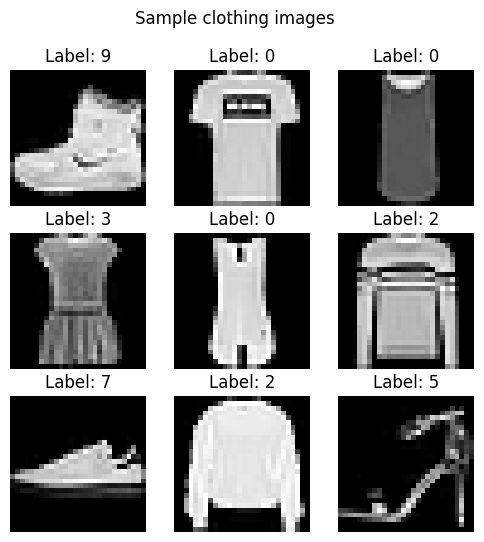

In [3]:
plt.figure(figsize=(6,6))
for i in range(9):
  plt.subplot(3,3,i+1)
  plt.imshow(X_train[i], cmap='gray')
  plt.title(f"Label: {y_train[i]}")
  plt.axis('off')
plt.suptitle("Sample clothing images")
plt.show()

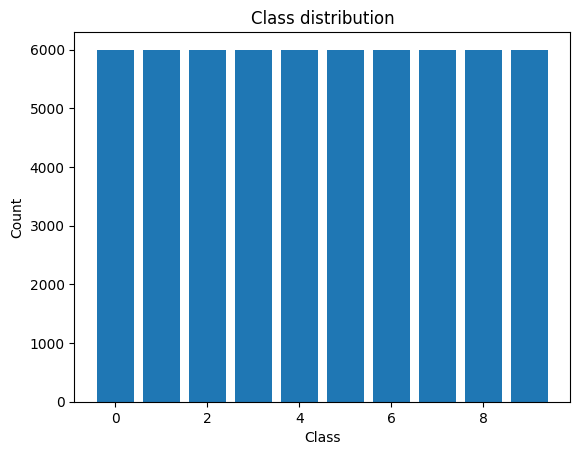

In [4]:
# check class balance
unique, counts = np.unique(y_train, return_counts=True)
plt.figure()
plt.bar(unique, counts)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class distribution")
plt.show()

In [5]:
# define neural network architecture
model = keras.Sequential([
    # flattens convert 2D images -> 1D vector
    layers.Flatten(input_shape=(28,28)),
    # hidden layers learn patterns
    layers.Dense(128, activation='relu'),
    # output layers -> 10 classes
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
history = model.fit(
    X_train, y_train,
    epochs = 15,
    validation_split = 0.2,
    batch_size = 32
)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8158 - loss: 0.5264 - val_accuracy: 0.8541 - val_loss: 0.4108
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8620 - loss: 0.3890 - val_accuracy: 0.8702 - val_loss: 0.3579
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8735 - loss: 0.3478 - val_accuracy: 0.8708 - val_loss: 0.3566
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8825 - loss: 0.3225 - val_accuracy: 0.8696 - val_loss: 0.3510
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8892 - loss: 0.3022 - val_accuracy: 0.8702 - val_loss: 0.3513
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8940 - loss: 0.2858 - val_accuracy: 0.8832 - val_loss: 0.3287
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8979 - loss: 0.2740 - val_accuracy: 0.8767 - val_loss: 0.3365
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9013 - loss: 0.2637 - 

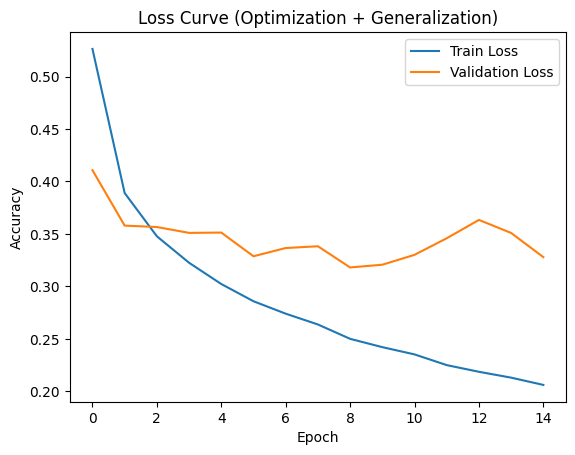

In [8]:
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss Curve (Optimization + Generalization)')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

In [9]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy: ", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8801 - loss: 0.3619
Test Accuracy:  0.8801000118255615


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


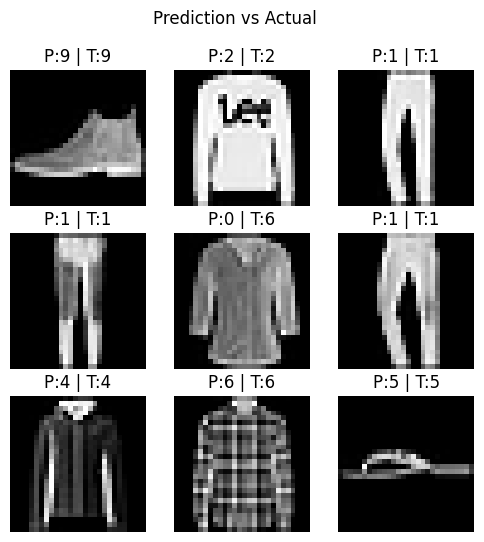

In [10]:
preds = model.predict(X_test[:9])
plt.figure(figsize=(6,6))
for i in range(9):
  plt.subplot(3,3,i+1)
  plt.imshow(X_test[i], cmap='gray')
  plt.title(f"P:{np.argmax(preds[i])} | T:{y_test[i]}")
  plt.axis('off')
plt.suptitle("Prediction vs Actual")
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


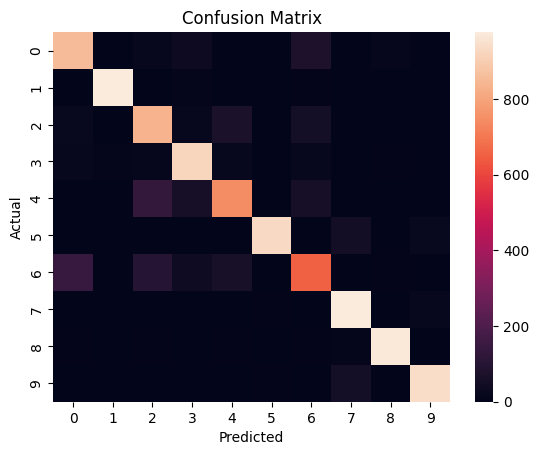

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
y_pred = np.argmax(model.predict(X_test), axis=1)
cm = confusion_matrix(y_test,y_pred)
plt.figure()
sns.heatmap(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()